# Hotel Booking Cancellation Analysis
---

## Import libraries

In [47]:
import pandas as pd
pd.set_option('display.max_columns',40)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid', context='paper')
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

## Load the data

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\Bhawna\OneDrive\Desktop\Hotel booking cancellation analysis\hotel_bookings.csv")

# Shape of the dataset
print(f'Shape of the dataset: {df.shape}\n')
# display top 5 rows
display(df.head())

Shape of the dataset: (119390, 32)



,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Checking null values, datatypes and unique values

In [3]:
# quick check dataframe
check_df = pd.DataFrame({
    'Features': df.columns,
    'Null Values': [df[c].isnull().sum() for c in df.columns],
    'Data Type': [df[c].dtypes for c in df.columns],
    'Unique Values': [df[c].nunique() for c in df.columns]
})

# display check_df with sorting
display(check_df.sort_values('Null Values', ascending=False))

,Features,Null Values,Data Type,Unique Values
24,company,112593,float64,352
23,agent,16340,float64,333
13,country,488,object,177
10,children,4,float64,5
4,arrival_date_month,0,object,12
5,arrival_date_week_number,0,int64,53
0,hotel,0,object,2
1,is_canceled,0,int64,2
7,stays_in_weekend_nights,0,int64,17
6,arrival_date_day_of_month,0,int64,31


## Data Cleaning

In [4]:
# Drop company feature because it has almost each row blank and
# it won't create much impact on our project
df.drop(['company'], axis=1, inplace=True)

In [5]:
# For agent feature, first i will fill null values with 0
# then i will change its data type float to int

# Fill null values
df['agent'] = df['agent'].fillna(0)

# Change its datatype
df['agent'] = df['agent'].astype(int)

In [6]:
# For country, i will fill null values with unknown country
# because if i assign it with mode then it may become bias

# Fill null values
df['country'] = df['country'].fillna('Unknown')

In [7]:
# For children, i will fill null values with 0
# and then change its datatype float to int

# Fill null values
df['children'] = df['children'].fillna(0)

# Change its datatype
df['children'] = df['children'].astype(int)

## Exploratory Data Analysis

Overall Cancellation Rate: 37.04%


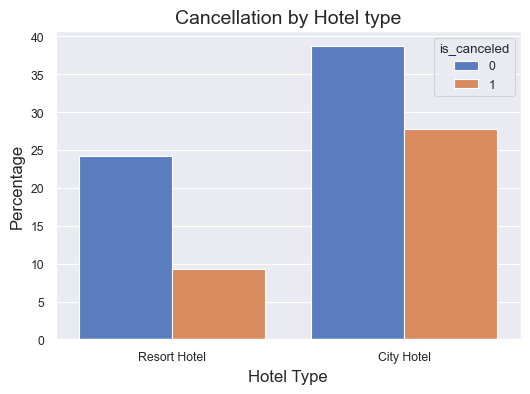

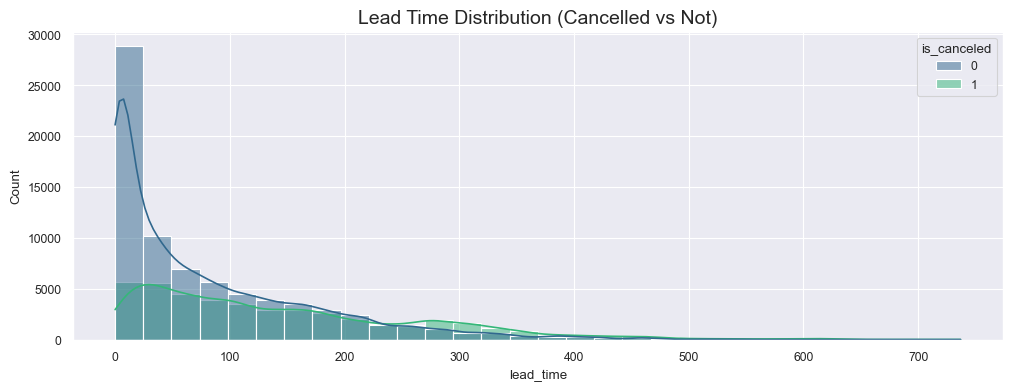

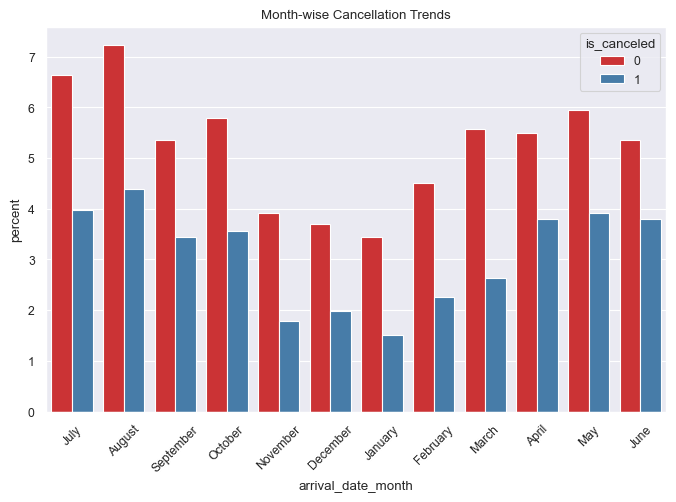

In [ ]:
# Cancellation Rate
cancel_rate = df['is_canceled'].mean() * 100
print(f"Overall Cancellation Rate: {cancel_rate:.2f}%")

# Cancellation percentage by Hotel type
plt.figure(figsize=(6,4))
sns.countplot(x=df['hotel'], hue=df['is_canceled'],
              palette='muted', stat='percent')
plt.title("Cancellation by Hotel type", fontsize=14)
plt.xlabel("Hotel Type", fontsize=12)
plt.ylabel("Percentage", fontsize=12)
plt.show()

# Lead time vs cancellation
plt.figure(figsize=(12,4))
sns.histplot(x=df['lead_time'], hue=df['is_canceled'], bins=30, kde=True, palette='viridis')
plt.title("Lead Time Distribution (Cancelled vs Not)", fontsize=14)
plt.show()

# Month wise cancellation
plt.figure(figsize=(8,5))
sns.countplot(x='arrival_date_month', hue='is_canceled', data=df, 
              order=df['arrival_date_month'].unique(), palette='Set1',
              stat='percent')
plt.title("Month-wise Cancellation Trends")
plt.xticks(rotation=45)
plt.show()

#

## KPIs

In [75]:
# Cancellation by Hotel Type
hotel_cancel = df.groupby('hotel')['is_canceled']\
                .mean() * 100
print(f'Cancellation by Hotel type: \n{hotel_cancel}\n')

# Average Lead Time (Canceled vs Non-Canceled)
lead_time = df.groupby('is_canceled')['lead_time'].mean()
print(f'Average Lead Time: \n{lead_time}\n')

# Deposit Type Impact
deposit_cancel = df.groupby('deposit_type')['is_canceled']\
    .mean() * 100
print(f'Deposit Type Impact: \n{deposit_cancel}\n')

# Month-wise Cancellation Rate
month_cancel = df.groupby('arrival_date_month')['is_canceled']\
    .mean() * 100
print(f'Month-wise Cancellation Rate: \n{month_cancel}\n')

# Average Daily Rate Comparison
adr_cancel = df.groupby('is_canceled')['adr'].mean()
print(f'ADR Comparison: \n{adr_cancel}\n')

# Special Requests Impact
requests_cancel = df.groupby('total_of_special_requests')['is_canceled']\
    .mean() * 100
print(f'Special Requests Impact: \n{requests_cancel}\n')

# Top 5 Countries by Cancellation
country_cancel = df.groupby('country')['is_canceled']\
    .mean() * 100
print(f'Top 5 Countries by Cancellation: \n{country_cancel.sort_values(ascending=False).head(5)}')


Cancellation by Hotel type: 
hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64

Average Lead Time: 
is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

Deposit Type Impact: 
deposit_type
No Deposit    28.377022
Non Refund    99.362446
Refundable    22.222222
Name: is_canceled, dtype: float64

Month-wise Cancellation Rate: 
arrival_date_month
April        40.797186
August       37.753117
December     34.970501
February     33.415964
January      30.477315
July         37.453598
June         41.457172
March        32.152338
May          39.665847
November     31.233441
October      38.046595
September    39.170156
Name: is_canceled, dtype: float64

ADR Comparison: 
is_canceled
0     99.987693
1    104.964333
Name: adr, dtype: float64

Special Requests Impact: 
total_of_special_requests
0    47.720356
1    22.024920
2    22.098851
3    17.861434
4    10.588235
5     5.000000
Name: is_canceled, dtype: float64

Top 5 Countri